# **Headpose Estimation with dlib**
Author: Aditya Khadkikar

Credit: https://github.com/fisakhan/Face_Pose/blob/master/pose_detection_retinaface.py

Original code from above adapted now to work for the DLIB runs.

> Because of the files being excessively large in size, outputs are not stored. Run the notebooks to achieve the outputs. You need the necessary libraries in this notebook, and a ZIP folder of all of the images named as `intra-sim.zip`.

In [ ]:
! pip install deepface

In [1]:
# @title
# built-in dependencies
import itertools, pickle
import math, os, glob, cv2
import matplotlib.pyplot as plt

# 3rd party dependencies
import pandas as pd, numpy as np
pd.set_option('display.max_rows', None)

from deepface import DeepFace
from deepface.modules.verification import find_distance, find_threshold
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from PIL import Image
from scipy import stats
import dlib

font = cv2.FONT_HERSHEY_SIMPLEX # Text in video
font_size = 0.4
blue = (0, 0, 255)
green = (0,128,0)
red = (255, 0, 0)

face_detector = dlib.get_frontal_face_detector()
landmark_detector = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

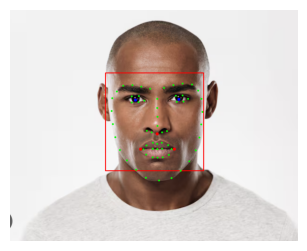

In [2]:
img_path = "tester1.png"
img = dlib.load_rgb_image(img_path)

landmark_tuple = {}

faces = face_detector(img, 1)
for k, d in enumerate(faces):
   landmark_tuple[k] = {
    'facial_area': [d.left(), d.top(), d.right(), d.bottom()],
    'right_eye': [],
    'left_eye': [],
    'nose': [],
    'mouth_right': [],
    'mouth_left': []
   }
   landmarks = landmark_detector(img, d)
   cv2.rectangle(img, (d.left(), d.top()), (d.right(), d.bottom()), red, 2)
   for n in range(0, 68):
      x = landmarks.part(n).x
      y = landmarks.part(n).y
      if n == 36: # 36, 39: right eye
        cv2.circle(img, ((x+landmarks.part(39).x)//2, (y+landmarks.part(39).y)//2), 5, (0, 0, 255), -1)
        landmark_tuple[k]['right_eye'] = [(x+landmarks.part(39).x)//2, (y+landmarks.part(39).y)//2]
      elif n == 42: # 45, 42: left eye
        cv2.circle(img, ((x+landmarks.part(45).x)//2, (y+landmarks.part(45).y)//2), 5, (0, 0, 255), -1)
        landmark_tuple[k]['left_eye'] = [(x+landmarks.part(45).x)//2, (y+landmarks.part(45).y)//2]
      elif n in [33, 48, 54]:     # 33: nose, 48: mouth_right, 54: mouth_left
        cv2.circle(img, (x, y), 5, (255, 0, 0), -1)
        if n == 33:
          landmark_tuple[k]["nose"] = [x, y]
        elif n == 48:
          landmark_tuple[k]["mouth_right"] = [x, y]
        else:
          landmark_tuple[k]["mouth_left"] = [x, y]
      else:
        cv2.circle(img, (x, y), 3, (0, 255, 0), -1)

plt.figure(figsize=(5, 3))
plt.imshow(img)
plt.axis('off')
plt.show()

In [3]:
landmark_tuple # here we cast it to have a return type similar to how e.g. retinaface returns

{0: {'facial_area': [312, 206, 633, 527],
  'right_eye': [410, 295],
  'left_eye': [552, 293],
  'nose': [481, 406],
  'mouth_right': [427, 456],
  'mouth_left': [537, 456]}}

In [24]:
def draw_landmarks(frame, bb, points):
    '''
    Parameters ----------
      frame : TYPE
          RGB image
      bb : TYPE - Array of float64, Size = (5,)
          coordinates of bounding box for the selected face.
      points : TYPE - Array of float32, Size = (10,)
          coordinates of landmarks for the selected faces.
    Returns ------- None.
    '''
    bb = bb.astype(int)
    points = points.astype(int)

    #print(bb)
    #print(points)

    # draw rectangle and landmarks on face
    cv2.rectangle(frame, (bb[0], bb[1]), (bb[2], bb[3]), red, 1)

    cv2.circle(frame, (points[4], points[5]), 2, blue, 2) # nose x,y
    cv2.circle(frame, (points[6], points[7]), 2, blue, 2) # mouth - right x,y
    cv2.circle(frame, (points[0], points[1]), 2, blue, 2) # right eye x,y
    cv2.circle(frame, (points[2], points[3]), 2, blue, 2) # left eye x,y
    cv2.circle(frame, (points[8], points[9]), 2, blue, 2) # mouth - left x,y

In [25]:
def find_pose(unflattened_points):
    """
    Parameters ---------- points : TYPE - Array of float32, Size = (10,), coordinates of landmarks for the selected faces.
    Returns ------- Angle, Yaw, Pitch
    """
    LMx = unflattened_points[:,0] # horizontal coordinates of landmarks
    LMy = unflattened_points[:,1] # vertical coordinates of landmarks

    dPx_eyes = max((LMx[1] - LMx[0]), 1) # x-dist between right and left eye
    dPy_eyes = (LMy[1] - LMy[0]) # y-dist between eyes
    angle = np.arctan(dPy_eyes / dPx_eyes) # angle for rotation based on slope eyes

    alpha = np.cos(angle)
    beta = np.sin(angle)

    # rotated landmarks
    LMxr = (alpha * LMx + beta * LMy + (1 - alpha) * LMx[2] / 2 - beta * LMy[2] / 2)
    LMyr = (-beta * LMx + alpha * LMy + beta * LMx[2] / 2 + (1 - alpha) * LMy[2] / 2)

    # average distance between eyes and mouth
    dXtot = (LMxr[1] - LMxr[0] + LMxr[4] - LMxr[3]) / 2
    dYtot = (LMyr[3] - LMyr[0] + LMyr[4] - LMyr[1]) / 2

    # average distance between nose and eyes
    dXnose = (LMxr[1] - LMxr[2] + LMxr[4] - LMxr[2]) / 2
    dYnose = (LMyr[3] - LMyr[2] + LMyr[4] - LMyr[2]) / 2

    # relative rotation
    # 0 degree = frontal, -90 degree = profile right, 90 degree = profile left (from viewer's perspective)
    Xfrontal = (-90+90 / 0.5 * dXnose / dXtot) if dXtot != 0 else 0
    Yfrontal = (-90+90 / 0.5 * dYnose / dYtot) if dYtot != 0 else 0

    Xfrontal = 180 if Xfrontal > 180 else Xfrontal
    Xfrontal = -180 if Xfrontal < -180 else Xfrontal
    Yfrontal = 180 if Yfrontal > 180 else Yfrontal
    Yfrontal = -180 if Yfrontal < -180 else Yfrontal

    return (angle * 180 / np.pi), Xfrontal, Yfrontal # 1st: roll, 2nd: yaw, 3rd: pitch

In [14]:
# ! unzip intra-sim.zip

In [ ]:
# @title
results = {}
not_recog = []

for person in glob.glob(f'intra-sim/*'):
  images = glob.glob(f'{person}/*.png')
  for image_path in images:
    # Read image (PNG) and convert to BGR for OpenCV drawing
    try:
        pil = Image.open(image_path).convert("RGB")
        frame = cv2.cvtColor(np.array(pil), cv2.COLOR_RGB2BGR)
        rets = True
    except Exception as e:
        print("Error reading image:", e)
        frame = None
        rets = False
        #not_recog += [image_path]

    if not rets or frame is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")
        #not_recog += [image_path]

    # Use the loaded image (do not flip by default; uncomment if you want)
    image_rgb = frame.copy()  # image in BGR order for OpenCV drawing

    try:
      detection = {}
      img = dlib.load_rgb_image(image_path)
      faces = face_detector(img, 1)

      for k, d in enumerate(faces):
        detection[k] = {
          'facial_area': [d.left(), d.top(), d.right(), d.bottom()],
          'landmarks': {
              'right_eye': [],
              'left_eye': [],
              'nose': [],
              'mouth_right': [],
              'mouth_left': []
          }
        }
        landmarks = landmark_detector(img, d)
        #cv2.rectangle(img, (d.left(), d.top()), (d.right(), d.bottom()), red, 1)
        for n in range(0, 68):
            x = landmarks.part(n).x
            y = landmarks.part(n).y
            if n == 36: # 36, 39: right eye
              cv2.circle(img, ((x+landmarks.part(39).x)//2, (y+landmarks.part(39).y)//2), 3, (0, 0, 255), -1)
              detection[k]['landmarks']['right_eye'] = [(x+landmarks.part(39).x)//2, (y+landmarks.part(39).y)//2]
            elif n == 42: # 45, 42: left eye
              cv2.circle(img, ((x+landmarks.part(45).x)//2, (y+landmarks.part(45).y)//2), 3, (0, 0, 255), -1)
              detection[k]['landmarks']['left_eye'] = [(x+landmarks.part(45).x)//2, (y+landmarks.part(45).y)//2]
            elif n in [33, 48, 54]:     # 33: nose, 48: mouth_right, 54: mouth_left
              cv2.circle(img, (x, y), 3, (255, 0, 0), -1)
              if n == 33:
                detection[k]['landmarks']["nose"] = [x, y]
              elif n == 48:
                detection[k]['landmarks']["mouth_right"] = [x, y]
              else:
                detection[k]['landmarks']["mouth_left"] = [x, y]
            else:
              cv2.circle(img, (x, y), 1, (0, 255, 0), -1)

      ## If multiple subjects in the image, just identify by num of bounding boxes -->
      print(image_path, list(detection.keys()))

      # if > 1: take the face with the largest confidence
      # but that is not the used solution. best to manually label.
      if len(list(detection.keys())) > 1:
        print("manually label, multiple faces present here!")
        not_recog += [image_path]

      # the actual primary subject's face could have slightly lower facial confidence score,
      # and model can mistakenly select a background person.
      # print([f'{key}: {detection[key]['score']}' for key in list(detection.keys())])

      bbs = np.array(detection[list(detection.keys())[0]]['facial_area'])
      lmarks_unflattened = np.array(list(detection[list(detection.keys())[0]]['landmarks'].values()))
      lmarks = lmarks_unflattened.flatten()
      #cv2.putText(image_rgb, 'identified face', (lmarks[4]+2, lmarks[5]+2), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 2)
    except Exception as e:
      print(e)
      bbs, lmarks, lmarks_unflattened = [], [], []
      cv2.putText(image_rgb, 'no face detected', (10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 2)

    # if at least one face is detected
    if len(bbs) > 0:
        # process only one face (center ?) if multiple faces detected
        draw_landmarks(image_rgb, bbs, lmarks)  # draw landmarks and bbox
        roll, yaw, pitch = find_pose(lmarks_unflattened)
        results[image_path] = {
            "person": person,
            "roll": roll,
            "yaw": yaw,
            "pitch": pitch
        }
        print("roll", roll, " -- yaw", yaw, " -- pitch", pitch)
    else:
        cv2.putText(image_rgb, 'no face detected', (10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 2)

    plt.figure(figsize=(5, 3))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

print("images to manually label:", len(not_recog))

In [ ]:
results

In [28]:
with open('dlib-headposes.pickle', 'wb') as handle:
    pickle.dump(results, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
not_recog # manually labelled in a separate occasion afterwards

['intra-sim/Gray_Davis_/7.png',
 'intra-sim/Gray_Davis_/19.png',
 'intra-sim/Gray_Davis_/6.png',
 'intra-sim/Tom_Daschle_/18.png',
 'intra-sim/Atal_Bihari_Vajpayee_/9.png',
 'intra-sim/John_Negroponte_/7.png',
 'intra-sim/John_Negroponte_/17.png',
 'intra-sim/Mahmoud_Abbas_/13.png',
 'intra-sim/Mahmoud_Abbas_/9.png',
 'intra-sim/Mahmoud_Abbas_/5.png',
 'intra-sim/Michael_Bloomberg_/5.png',
 'intra-sim/Roh_Moo-hyun_/3.png',
 'intra-sim/Roh_Moo-hyun_/12.png',
 'intra-sim/George_Robertson_/6.png',
 'intra-sim/Hamid_Karzai_/2.png',
 'intra-sim/Colin_Powell_/16.png',
 'intra-sim/Colin_Powell_/8.png',
 'intra-sim/Colin_Powell_/6.png',
 'intra-sim/Amelie_Mauresmo_/14.png',
 'intra-sim/Jiang_Zemin_/8.png',
 'intra-sim/Andre_Agassi_/4.png',
 'intra-sim/Recep_Tayyip_Erdogan_/15.png',
 'intra-sim/Recep_Tayyip_Erdogan_/13.png',
 'intra-sim/Recep_Tayyip_Erdogan_/14.png',
 'intra-sim/Recep_Tayyip_Erdogan_/11.png',
 'intra-sim/Tony_Blair_/10.png',
 'intra-sim/Rudolph_Giuliani_/10.png',
 'intra-sim/Ru